# ML4SCI DeepFalcon GSoC 2026 — Common Task 2
## Graph Neural Network for Quark/Gluon Jet Classification

Jets are represented as graphs of energy deposits rather than fixed-size images.
This approach discards empty pixels, preserves spatial relationships between 
active detector hits, and allows a GNN to learn jet structure directly from 
the graph topology.

## Setup

In [ ]:
import gdown
gdown.download("https://drive.google.com/uc?id=1WO2K-SfU2dntGU4Bb3IYBp9Rh7rtTYEr", 
               "quark-gluon_data-set_n139306.hdf5")

In [24]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
import gc
from tqdm import tqdm
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, global_mean_pool, knn_graph
from torch_geometric.loader import DataLoader as GeoDataLoader
from sklearn.metrics import roc_auc_score, confusion_matrix

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


## Step 1: Images → Point Clouds

Each jet image is 125×125 pixels across 3 channels, but ~98% of pixels are zero.
Processing the full grid wastes computation on empty space. Instead we extract 
only the active pixels — those where at least one channel is non-zero.

Each active pixel becomes a point with 5 values:
- row, col: its spatial position in the image
- ECAL, HCAL, Tracks: energy deposit values at that location

This is the point cloud representation of a jet.

In [25]:
with h5py.File("quark-gluon_data-set_n139306.hdf5", 'r') as f:
    img   = f["X_jets"][0].astype(np.float32)
    label = f["y"][0]

mask   = (img != 0).any(axis=2)
coords = np.argwhere(mask).astype(np.float32)
feats  = img[mask]

print(f"Total pixels:  {125*125}")
print(f"Active pixels: {len(coords)}")
print(f"Label: {'quark' if label == 1.0 else 'gluon'}")

point_cloud = np.concatenate([coords, feats], axis=1)
print(f"\nPoint cloud shape: {point_cloud.shape}")
print("First 5 points [row, col, ECAL, HCAL, Tracks]:")
print(point_cloud[:5])

Total pixels:  15625
Active pixels: 884
Label: gluon

Point cloud shape: (884, 5)
First 5 points [row, col, ECAL, HCAL, Tracks]:
[[0.0000000e+00 1.0000000e+01 9.3509732e-03 0.0000000e+00 0.0000000e+00]
 [0.0000000e+00 9.5000000e+01 0.0000000e+00 1.3646677e-03 0.0000000e+00]
 [1.0000000e+00 1.0500000e+02 2.8167365e-03 0.0000000e+00 0.0000000e+00]
 [2.0000000e+00 5.0000000e+01 9.2031984e-03 0.0000000e+00 0.0000000e+00]
 [2.0000000e+00 5.5000000e+01 6.0559358e-03 0.0000000e+00 0.0000000e+00]]


## Step 2: Point Clouds → Graphs

A graph consists of nodes and edges:
- Each active pixel becomes a node with 3 features (ECAL, HCAL, Tracks energy)
- Edges connect each node to its 8 spatially nearest neighbors (k-NN graph)

This encodes the local structure of energy deposits — nearby detector hits 
are connected, distant ones are not. The spatial coordinates are used only 
to define connectivity, not as node features.

Nodes: 884
Edges: 7072


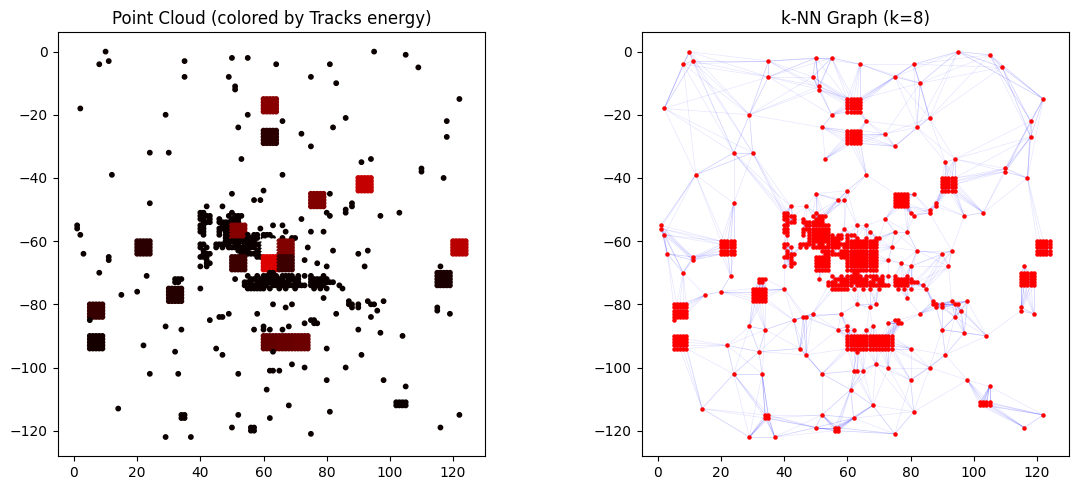

In [26]:
xy         = torch.from_numpy(coords)
x          = torch.from_numpy(feats)
edge_index = knn_graph(xy, k=8)

print(f"Nodes: {x.shape[0]}")
print(f"Edges: {edge_index.shape[1]}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(xy[:, 1], -xy[:, 0], c=x[:, 2], cmap="hot", s=10)
axes[0].set_title("Point Cloud (colored by Tracks energy)")
axes[0].set_aspect("equal")

for i in range(edge_index.shape[1]):
    src = edge_index[0, i].item()
    tgt = edge_index[1, i].item()
    axes[1].plot([xy[src,1], xy[tgt,1]], [-xy[src,0], -xy[tgt,0]],
                 'b-', alpha=0.1, linewidth=0.5)
axes[1].scatter(xy[:, 1], -xy[:, 0], c='red', s=5, zorder=3)
axes[1].set_title("k-NN Graph (k=8)")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

## Step 3: Building the Full Graph Dataset

We convert 50,000 jet images into graphs. Each graph is stored as a 
PyTorch Geometric Data object containing node features, edge connectivity, 
and the jet label.

Images are loaded into RAM first, then processed — opening the HDF5 file 
once rather than per-sample reduces processing time from hours to seconds.

In [27]:
def image_to_graph(img, label, k=8):
    mask   = (img != 0).any(axis=2)
    coords = np.argwhere(mask).astype(np.float32)
    feats  = img[mask]
    if len(coords) == 0:
        return None
    xy         = torch.from_numpy(coords)
    x          = torch.from_numpy(feats)
    edge_index = knn_graph(xy, k=min(k, len(coords)-1))
    return Data(x=x, edge_index=edge_index, y=torch.tensor([int(label)]))

In [28]:
N_SAMPLES = 50000

print("Loading images...")
with h5py.File("quark-gluon_data-set_n139306.hdf5", 'r') as f:
    X_raw = f["X_jets"][:N_SAMPLES].astype(np.float32)
    y_raw = f["y"][:N_SAMPLES]

print("Building graphs...")
graphs = []
for i in tqdm(range(N_SAMPLES)):
    g = image_to_graph(X_raw[i], y_raw[i])
    if g is not None:
        graphs.append(g)

del X_raw, y_raw
gc.collect()

print(f"Built {len(graphs)} graphs")

random.seed(42)
random.shuffle(graphs)

n_train = int(len(graphs) * 0.8)
n_val   = int(len(graphs) * 0.1)

train_graphs = graphs[:n_train]
val_graphs   = graphs[n_train:n_train + n_val]
test_graphs  = graphs[n_train + n_val:]

train_loader = GeoDataLoader(train_graphs, batch_size=64, shuffle=True)
val_loader   = GeoDataLoader(val_graphs,   batch_size=64, shuffle=False)
test_loader  = GeoDataLoader(test_graphs,  batch_size=64, shuffle=False)

print(f"Train: {len(train_graphs)} | Val: {len(val_graphs)} | Test: {len(test_graphs)}")

Loading images...
Building graphs...


100%|██████████| 50000/50000 [01:31<00:00, 543.92it/s]


Built 50000 graphs
Train: 40000 | Val: 5000 | Test: 5000


## Model Architecture

We use a Graph Convolutional Network (GCN) with three message-passing layers.
Each layer updates every node's features by aggregating information from its 
connected neighbors. After three rounds of message passing, each node has a 
representation that reflects its local neighborhood in the jet.

Global mean pooling then averages all node representations into a single 
fixed-size vector per jet — necessary because different jets have different 
numbers of nodes. This vector is passed to a two-layer classifier.

Architecture summary:
- GCNConv(3 → 64) → ReLU
- GCNConv(64 → 128) → ReLU  
- GCNConv(128 → 256) → ReLU
- Global Mean Pool → (256,)
- Linear(256 → 64) → ReLU
- Linear(64 → 1) → sigmoid

In [29]:
class JetGNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(3,   64)
        self.conv2 = GCNConv(64, 128)
        self.conv3 = GCNConv(128, 256)
        self.fc1   = nn.Linear(256, 64)
        self.fc2   = nn.Linear(64, 1)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model = JetGNN().to(DEVICE)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Total parameters: 58,113


In [30]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

def train_epoch(loader):
    model.train()
    total_loss = correct = total = 0
    for batch in loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        out  = model(batch.x, batch.edge_index, batch.batch).squeeze()
        loss = F.binary_cross_entropy_with_logits(out, batch.y.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pred    = (out > 0).long()
        correct += (pred == batch.y).sum().item()
        total   += len(batch.y)
    return total_loss / len(loader), correct / total

@torch.no_grad()
def eval_epoch(loader):
    model.eval()
    total_loss = correct = total = 0
    for batch in loader:
        batch = batch.to(DEVICE)
        out  = model(batch.x, batch.edge_index, batch.batch).squeeze()
        loss = F.binary_cross_entropy_with_logits(out, batch.y.float())
        total_loss += loss.item()
        pred    = (out > 0).long()
        correct += (pred == batch.y).sum().item()
        total   += len(batch.y)
    return total_loss / len(loader), correct / total

EPOCHS       = 30
best_val_acc = 0.0
history      = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(train_loader)
    va_loss, va_acc = eval_epoch(val_loader)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    scheduler.step(va_loss)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), "gnn_best.pt")

    print(f"Epoch {epoch:3d}/{EPOCHS} | "
          f"Train loss: {tr_loss:.4f} acc: {tr_acc:.4f} | "
          f"Val loss: {va_loss:.4f} acc: {va_acc:.4f}")

print(f"\nBest val accuracy: {best_val_acc:.4f}")

Epoch   1/30 | Train loss: 0.6261 acc: 0.6555 | Val loss: 0.5818 acc: 0.7056
Epoch   2/30 | Train loss: 0.5968 acc: 0.6933 | Val loss: 0.5854 acc: 0.7024
Epoch   3/30 | Train loss: 0.5907 acc: 0.6953 | Val loss: 0.5763 acc: 0.7078
Epoch   4/30 | Train loss: 0.5888 acc: 0.6940 | Val loss: 0.5781 acc: 0.7104
Epoch   5/30 | Train loss: 0.5884 acc: 0.6951 | Val loss: 0.5756 acc: 0.7088
Epoch   6/30 | Train loss: 0.5892 acc: 0.6939 | Val loss: 0.5740 acc: 0.7118
Epoch   7/30 | Train loss: 0.5879 acc: 0.6953 | Val loss: 0.5782 acc: 0.7102
Epoch   8/30 | Train loss: 0.5861 acc: 0.6975 | Val loss: 0.5801 acc: 0.7024
Epoch   9/30 | Train loss: 0.5862 acc: 0.6955 | Val loss: 0.5729 acc: 0.7090
Epoch  10/30 | Train loss: 0.5860 acc: 0.6977 | Val loss: 0.5734 acc: 0.7120
Epoch  11/30 | Train loss: 0.5859 acc: 0.6956 | Val loss: 0.5768 acc: 0.7078
Epoch  12/30 | Train loss: 0.5860 acc: 0.6963 | Val loss: 0.5741 acc: 0.7096
Epoch  13/30 | Train loss: 0.5858 acc: 0.6953 | Val loss: 0.5745 acc: 0.7086

## Results

### Training Performance
The model was trained for 30 epochs on 40,000 jets, validated on 5,000 after 
each epoch. Best validation accuracy was achieved at epoch 26.

### Test Set Performance
- **Test Accuracy: 70.9%**
- **Test AUC: 0.77**

An AUC of 0.77 means the model correctly ranks a random quark jet above a 
random gluon jet 77% of the time — significantly better than random (0.50).

### Confusion Matrix
The model is well balanced across both classes, correctly identifying 1730 
gluon jets and 1818 quark jets out of 5,000 test samples.

In [31]:
model.load_state_dict(torch.load("gnn_best.pt", map_location=DEVICE))
model.eval()

all_preds  = []
all_labels = []
all_scores = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(DEVICE)
        out   = model(batch.x, batch.edge_index, batch.batch).squeeze()
        score = torch.sigmoid(out).cpu().numpy()
        pred  = (out > 0).long().cpu().numpy()
        all_scores.extend(score)
        all_preds.extend(pred)
        all_labels.extend(batch.y.cpu().numpy())

all_scores = np.array(all_scores)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc = (all_preds == all_labels).mean()
auc = roc_auc_score(all_labels, all_scores)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test AUC:      {auc:.4f}")

cm = confusion_matrix(all_labels, all_preds)
print(f"\nConfusion Matrix:")
print(f"              Pred Gluon  Pred Quark")
print(f"True Gluon    {cm[0,0]:6d}      {cm[0,1]:6d}")
print(f"True Quark    {cm[1,0]:6d}      {cm[1,1]:6d}")

Test Accuracy: 0.7090
Test AUC:      0.7680

Confusion Matrix:
              Pred Gluon  Pred Quark
True Gluon      1698         828
True Quark       627        1847


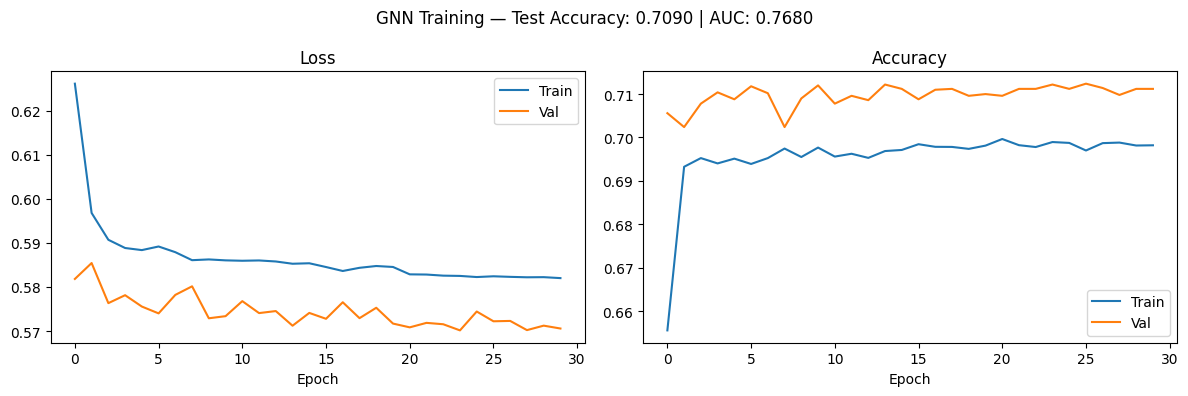

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"],   label="Val")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(history["train_acc"], label="Train")
ax2.plot(history["val_acc"],   label="Val")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.suptitle(f"GNN Training — Test Accuracy: {acc:.4f} | AUC: {auc:.4f}")
plt.tight_layout()
plt.savefig("gnn_results.png", dpi=150)
plt.show()

## Analysis

The GNN achieves 70.9% test accuracy and 0.77 AUC on 50,000 jets.

Key observations:
- Validation accuracy is consistently higher than train accuracy — 
  the model generalizes well with no overfitting
- AUC of 0.77 means the model correctly ranks a random quark jet 
  above a random gluon jet 77% of the time
- The confusion matrix is balanced — the model is not biased toward 
  predicting one class
- Scaling from 5,000 to 50,000 jets improved AUC from 0.74 to 0.77, 
  suggesting the full dataset would yield further gains

Limitations:
- Simple GCN architecture — EdgeConv or GAT would likely perform better
- k=8 neighbors is a fixed choice — tuning k could improve results
- Node features use only energy values, not normalized coordinates

## Conclusion

Graph Neural Networks provide a natural and efficient representation for 
jet classification. By discarding the 98% of empty pixels and encoding 
spatial relationships between active energy deposits as graph edges, the 
GNN learns jet structure directly from detector geometry rather than a 
fixed pixel grid.

The simple GCN baseline achieves 70.9% accuracy and 0.77 AUC on 50,000 
jets. Scaling from 5,000 to 50,000 jets improved AUC from 0.74 to 0.77, 
suggesting the full 139,306 jet dataset would yield further gains.

Potential improvements:
- EdgeConv or Graph Attention Networks (GAT) instead of simple GCN
- Include normalized spatial coordinates as additional node features
- Tune k in the k-NN graph construction
- Train on the full dataset